# E-commerce Customer Behaviour Analysis & Recommendations

Step 1: Import Libraries

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

Step 2: Load All CSV Files

In [135]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3) (2).zip


In [136]:
import zipfile
import os

zip_file = 'archive (3).zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('olist_data')

print("Files Extracted Successfully!")

Files Extracted Successfully!


In [137]:
os.listdir('olist_data')

['olist_customers_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv']

In [138]:
customers = pd.read_csv('/content/olist_data/olist_customers_dataset.csv')

orders = pd.read_csv('/content/olist_data/olist_orders_dataset.csv')

order_items = pd.read_csv('/content/olist_data/olist_order_items_dataset.csv')

payments = pd.read_csv('/content/olist_data/olist_order_payments_dataset.csv')

reviews = pd.read_csv('/content/olist_data/olist_order_reviews_dataset.csv')

products = pd.read_csv('/content/olist_data/olist_products_dataset.csv')

sellers = pd.read_csv('/content/olist_data/olist_sellers_dataset.csv')

geo = pd.read_csv('/content/olist_data/olist_geolocation_dataset.csv')

category = pd.read_csv('/content/olist_data/product_category_name_translation.csv')

Step 3: Verify Data Loaded Correctly

In [139]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geo:", geo.shape)
print("Category Translation:", category.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geo: (1000163, 5)
Category Translation: (71, 2)


Step 4: Preview Datasets

In [140]:
# Preview All Datasets

print("CUSTOMERS DATASET")
display(customers.head())

print("ORDERS DATASET")
display(orders.head())

print("ORDER ITEMS DATASET")
display(order_items.head())

print("PAYMENTS DATASET")
display(payments.head())

print("REVIEWS DATASET")
display(reviews.head())

print("PRODUCTS DATASET")
display(products.head())

print("SELLERS DATASET")
display(sellers.head())

print("GEOLOCATION DATASET")
display(geo.head())

print("CATEGORY TRANSLATION DATASET")
display(category.head())

CUSTOMERS DATASET


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDERS DATASET


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


ORDER ITEMS DATASET


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


GEOLOCATION DATASET


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


CATEGORY TRANSLATION DATASET


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [141]:
# Preview All Tables/Datasets

datasets = {
    "CUSTOMERS DATASET": customers,
    "ORDERS DATASET": orders,
    "ORDER ITEMS DATASET": order_items,
    "PAYMENTS DATASET": payments,
    "REVIEWS DATASET": reviews,
    "PRODUCTS DATASET": products,
    "SELLERS DATASET": sellers,
    "GEOLOCATION DATASET": geo,
    "CATEGORY TRANSLATION DATASET": category
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nShape of Dataset:")
    print(df.shape)

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\nData Types:")
    display(df.dtypes)

    print("\nMissing Values:")
    display(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\n\n")

CUSTOMERS DATASET

Shape of Dataset:
(99441, 5)

Column Names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

First 5 Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Data Types:


,0
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



Missing Values:


...


Data Types:


,0
product_category_name,object
product_category_name_english,object



Missing Values:


,0
product_category_name,0
product_category_name_english,0



Duplicate Rows:
0





Step 5.1: Checking Missing Values

In [142]:
# CHECK MISSING VALUES FOR ALL DATASETS

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geo": geo,
    "category_translation": category
}

for name, df in datasets.items():

    print("="*70)
    print(f"MISSING VALUE ANALYSIS : {name.upper()}")
    print("="*70)

    # Total Missing Values
    missing_values = df.isnull().sum()

    # Percentage Missing
    missing_percentage = (
        (df.isnull().sum() / len(df)) * 100
    ).round(2)

    # Combine into DataFrame
    missing_df = pd.DataFrame({
        'Column_Name': df.columns,
        'Missing_Values': missing_values.values,
        'Missing_Percentage': missing_percentage.values
    })

    # Show only columns with missing values
    missing_df = missing_df[
        missing_df['Missing_Values'] > 0
    ].sort_values(
        by='Missing_Values',
        ascending=False
    )

    if missing_df.empty:
        print("No Missing Values Found.\n")
    else:
        display(missing_df)

    print("\n\n")

MISSING VALUE ANALYSIS : CUSTOMERS
No Missing Values Found.




MISSING VALUE ANALYSIS : ORDERS


,Column_Name,Missing_Values,Missing_Percentage
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
4,order_approved_at,160,0.16





MISSING VALUE ANALYSIS : ORDER_ITEMS
No Missing Values Found.




MISSING VALUE ANALYSIS : PAYMENTS
No Missing Values Found.




MISSING VALUE ANALYSIS : REVIEWS


,Column_Name,Missing_Values,Missing_Percentage
3,review_comment_title,87656,88.34
4,review_comment_message,58247,58.70





MISSING VALUE ANALYSIS : PRODUCTS


,Column_Name,Missing_Values,Missing_Percentage
1,product_category_name,610,1.85
2,product_name_lenght,610,1.85
3,product_description_lenght,610,1.85
4,product_photos_qty,610,1.85
5,product_weight_g,2,0.01
6,product_length_cm,2,0.01
7,product_height_cm,2,0.01
8,product_width_cm,2,0.01





MISSING VALUE ANALYSIS : SELLERS
No Missing Values Found.




MISSING VALUE ANALYSIS : GEO
No Missing Values Found.




MISSING VALUE ANALYSIS : CATEGORY_TRANSLATION
No Missing Values Found.






5.2: Missing Values Summary Table

In [143]:
# CREATE FINAL MISSING VALUE SUMMARY

missing_summary = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()

    missing_summary.append({
        'Dataset': name,
        'Total Missing Values': total_missing,
        'Total Rows': df.shape[0],
        'Total Columns': df.shape[1]
    })

missing_summary_df = pd.DataFrame(missing_summary)

display(missing_summary_df)

,Dataset,Total Missing Values,Total Rows,Total Columns
0,customers,0,99441,5
1,orders,4908,99441,8
2,order_items,0,112650,7
3,payments,0,103886,5
4,reviews,145903,99224,7
5,products,2448,32951,9
6,sellers,0,3095,4
7,geo,0,1000163,5
8,category_translation,0,71,2


**Reasons for Missing Values**

* **`orders → order_delivered_customer_date`**

  * Missing because the order has not been delivered yet.

* **`reviews → review_comment_message`**

  * Missing because customers skipped writing comments/reviews.

* **`products → product_category_name`**

  * Missing due to unavailable or incomplete product metadata.

* **`products → dimensions/weight`**

  * Missing because sellers did not provide complete product details.


**HANDLE MISSING VALUES IN ORDERS DATASET**

In [144]:
orders[orders.isnull().any(axis=1)].head() #Check Missing Rows

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00


**Convert Date Columns First**

In [145]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

**Handle order_approved_at**

In [146]:
orders['order_approved_at'].fillna(
    orders['order_purchase_timestamp'],
    inplace=True
)

/tmp/ipykernel_18236/1524609529.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['order_approved_at'].fillna(


**Handle order_delivered_carrier_date**

In [147]:
orders['order_delivered_carrier_date'].fillna(
    orders['order_approved_at'],
    inplace=True
)

/tmp/ipykernel_18236/3832012928.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['order_delivered_carrier_date'].fillna(


**Handle order_delivered_customer_date**

In [148]:
orders['delivery_status'] = np.where(
    orders['order_delivered_customer_date'].isnull(),
    'Not Delivered',
    'Delivered'
)

**Verify Missing Values Again**

In [149]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_status,0


HANDLE MISSING VALUES IN REVIEWS DATASET

**Fill Review Titles**

In [150]:
reviews['review_comment_title'].fillna(
    'No Title',
    inplace=True
)

/tmp/ipykernel_18236/422348161.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews['review_comment_title'].fillna(


**Fill Review Messages**

In [151]:
reviews['review_comment_message'].fillna(
    'No Comment',
    inplace=True
)

/tmp/ipykernel_18236/4135528050.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews['review_comment_message'].fillna(


**Verify Reviews Missing Values**

In [152]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


HANDLE MISSING VALUES IN PRODUCTS DATASET

**Handle Product Category**

In [153]:
products['product_category_name'].fillna(
    'Unknown',
    inplace=True
)

/tmp/ipykernel_18236/3440666398.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna(


**Handle Product Name Length**

In [154]:
products['product_name_lenght'].fillna(
    products['product_name_lenght'].median(),
    inplace=True
)

/tmp/ipykernel_18236/4275516897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_name_lenght'].fillna(


**Handle Product Description Length**

In [155]:
products['product_description_lenght'].fillna(
    products['product_description_lenght'].median(),
    inplace=True
)

/tmp/ipykernel_18236/4034611758.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_description_lenght'].fillna(


**Handle Product Photos Quantity**

In [156]:
products['product_photos_qty'].fillna(
    products['product_photos_qty'].median(),
    inplace=True
)

/tmp/ipykernel_18236/2361647512.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_photos_qty'].fillna(


**Handle Weight & Dimensions**

**Weight**

In [157]:
products['product_weight_g'].fillna(
    products['product_weight_g'].median(),
    inplace=True
)

/tmp/ipykernel_18236/2230865105.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_weight_g'].fillna(


**Length**

In [158]:
products['product_length_cm'].fillna(
    products['product_length_cm'].median(),
    inplace=True
)

/tmp/ipykernel_18236/1692434617.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_length_cm'].fillna(


**Height**

In [159]:
products['product_height_cm'].fillna(
    products['product_height_cm'].median(),
    inplace=True
)

/tmp/ipykernel_18236/772822453.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_height_cm'].fillna(


**Width**

In [160]:
products['product_width_cm'].fillna(
    products['product_width_cm'].median(),
    inplace=True
)

/tmp/ipykernel_18236/932790280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_width_cm'].fillna(


**Verify Products Missing Values**

In [161]:
products.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Final Missing Value Check**

In [162]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geo": geo,
    "category_translation": category
}

for name, df in datasets.items():

    print("="*60)
    print(name.upper())
    print("="*60)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No Missing Values Remaining\n")
    else:
        print(missing)

CUSTOMERS
No Missing Values Remaining

ORDERS
order_delivered_customer_date    2965
dtype: int64
ORDER_ITEMS
No Missing Values Remaining

PAYMENTS
No Missing Values Remaining

REVIEWS
No Missing Values Remaining

PRODUCTS
No Missing Values Remaining

SELLERS
No Missing Values Remaining

GEO
No Missing Values Remaining

CATEGORY_TRANSLATION
No Missing Values Remaining



**Check Duplicate Rows in All Tables**

In [163]:
# CHECK DUPLICATES IN ALL DATASETS

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geo": geo,
    "category_translation": category
}

duplicate_summary = []

for name, df in datasets.items():

    total_duplicates = df.duplicated().sum()

    duplicate_percentage = (
        total_duplicates / len(df)
    ) * 100

    duplicate_summary.append({
        'Dataset': name,
        'Total Rows': len(df),
        'Duplicate Rows': total_duplicates,
        'Duplicate Percentage': round(duplicate_percentage, 2)
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

display(duplicate_summary_df)

,Dataset,Total Rows,Duplicate Rows,Duplicate Percentage
0,customers,99441,0,0.00
1,orders,99441,0,0.00
2,order_items,112650,0,0.00
3,payments,103886,0,0.00
4,reviews,99224,0,0.00
5,products,32951,0,0.00
6,sellers,3095,0,0.00
7,geo,1000163,261831,26.18
8,category_translation,71,0,0.00


**Special Case: GEO Dataset**

IMPORTANT:
The geo dataset naturally contains repeated zip codes hence so many duplicate values.

In [164]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [165]:
geo['geolocation_zip_code_prefix'].duplicated().sum()

np.int64(981148)

**Check duplicate zip codes:**

In [166]:
geo = geo.drop_duplicates(
    subset=['geolocation_zip_code_prefix']
)

In [167]:
geo.duplicated().sum()

np.int64(0)

In [168]:
print("Duplicate Rows Remaining in GEO:")
print(geo.duplicated().sum())

Duplicate Rows Remaining in GEO:
0


**Convert Date Columns**

In [169]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
delivery_status,object


In [170]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors='coerce'
    )

Why Use errors='coerce'?

Very important.

If invalid dates exist:

they become NaT
instead of crashing notebook

**Verify Conversion**

In [171]:
orders[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


**Check Null Dates After Conversion**

In [172]:
orders[date_columns].isnull().sum()

,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Creation of Time-Based Features**

It's very important for EDA.

**Extract Year**

In [173]:
orders['order_year'] = (
    orders['order_purchase_timestamp']
    .dt.year
)

**Extract Month**

In [174]:
orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.month
)

Extract Month Name

In [175]:
orders['order_month_name'] = (
    orders['order_purchase_timestamp']
    .dt.month_name()
)

**Extract Day**

In [176]:
orders['order_day'] = (
    orders['order_purchase_timestamp']
    .dt.day
)

**Extract Day Name**

In [177]:
orders['order_day_name'] = (
    orders['order_purchase_timestamp']
    .dt.day_name()
)

**Extract Hour**

In [178]:
orders['order_hour'] = (
    orders['order_purchase_timestamp']
    .dt.hour
)

**Create Delivery Time Metrics**

**Delivery Days**

Formula:

Delivery Days=Delivery Date − Purchase Date

In [179]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

**Approval Time**

In [180]:
orders['approval_days'] = (
    orders['order_approved_at']
    - orders['order_purchase_timestamp']
).dt.days

**Carrier Shipping Time**

In [181]:
orders['carrier_delivery_days'] = (
    orders['order_delivered_carrier_date']
    - orders['order_approved_at']
).dt.days

**Verify Engineered Features**

In [182]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_status,order_year,order_month,order_month_name,order_day,order_day_name,order_hour,delivery_days,approval_days,carrier_delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,10,October,2,Monday,10,8.0,0,2
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Delivered,2018,7,July,24,Tuesday,20,13.0,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Delivered,2018,8,August,8,Wednesday,8,9.0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Delivered,2017,11,November,18,Saturday,19,13.0,0,3
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Delivered,2018,2,February,13,Tuesday,21,2.0,0,0


**Merge Category Translation (Detailed)**

**Inspect Category Translation Table**

In [183]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Check Products Dataset Before Merge**

In [184]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Merge Translation Table**

In [185]:
products = products.merge(
    category,
    on='product_category_name',
    how='left'
)

**Verify Merge**

In [186]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


**Check Missing English Categories**

In [187]:
products[
    products['product_category_name_english'].isnull()
].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
105,a41e356c76fab66334f36de622ecbd3a,Unknown,51.0,595.0,1.0,650.0,17.0,14.0,12.0,NaN
128,d8dee61c2034d6d075997acef1870e9b,Unknown,51.0,595.0,1.0,300.0,16.0,7.0,20.0,NaN
145,56139431d72cd51f19eb9f7dae4d1617,Unknown,51.0,595.0,1.0,200.0,20.0,20.0,20.0,NaN
154,46b48281eb6d663ced748f324108c733,Unknown,51.0,595.0,1.0,18500.0,41.0,30.0,41.0,NaN
197,5fb61f482620cb672f5e586bb132eae9,Unknown,51.0,595.0,1.0,300.0,35.0,7.0,12.0,NaN


**Some may still be null because:**



*   original category missing
*   translation unavailable




**Fill Missing English Categories**

In [188]:
products['product_category_name_english'].fillna(
    'Unknown',
    inplace=True
)

/tmp/ipykernel_18236/903358417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name_english'].fillna(


**Compare Before vs After**

**Unique Portuguese Categories**

In [189]:
products['product_category_name'].nunique()

74

**Unique English Categories**

In [190]:
products['product_category_name_english'].nunique()

72

**Check Top Categories**

In [191]:
products[
    'product_category_name_english'
].value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
auto,1900
computers_accessories,1639
toys,1411
watches_gifts,1329


**Merge Datasets**

Check Dataset Shapes Before Merge

In [192]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)

Customers: (99441, 5)
Orders: (99441, 18)
Order Items: (112650, 7)
Products: (32951, 10)
Payments: (103886, 5)
Reviews: (99224, 7)


**Start with Orders Table**

In [193]:
master_df = orders.merge(
    customers,
    on='customer_id',
    how='left',
    validate='many_to_one'
)

In [194]:
master_df.shape

(99441, 22)

In [195]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_status', 'order_year', 'order_month', 'order_month_name',
       'order_day', 'order_day_name', 'order_hour', 'delivery_days',
       'approval_days', 'carrier_delivery_days', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

**Merge Order Items**

In [196]:
master_df = master_df.merge(
    order_items,
    on='order_id',
    how='left',
    validate='one_to_many'
)

In [197]:
master_df.shape

(113425, 28)

**Merge Products Dataset**

In [198]:
master_df = master_df.merge(
    products,
    on='product_id',
    how='left',
    validate='many_to_one'
)

In [199]:
master_df.shape

(113425, 37)

**Merge Payments Dataset**

In [200]:
master_df = master_df.merge(
    payments,
    on='order_id',
    how='left',
    validate='many_to_many'
)

**Merge Reviews Dataset**

In [201]:
master_df = master_df.merge(
    reviews,
    on='order_id',
    how='left',
    validate='many_to_many'
)

**Verify Final Shape**

In [202]:
print(master_df.shape)

(119143, 47)


In [203]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_status,order_year,order_month,order_month_name,order_day,order_day_name,order_hour,delivery_days,approval_days,carrier_delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,10,October,2,Monday,10,8.0,0,2,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,10,October,2,Monday,10,8.0,0,2,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Delivered,2017,10,October,2,Monday,10,8.0,0,2,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Delivered,2018,7,July,24,Tuesday,20,13.0,1,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Delivered,2018,8,August,8,Wednesday,8,9.0,0,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18 00:00:00,2018-08-22 19:07:58


**Check Final Columns**

In [204]:
master_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_status',
 'order_year',
 'order_month',
 'order_month_name',
 'order_day',
 'order_day_name',
 'order_hour',
 'delivery_days',
 'approval_days',
 'carrier_delivery_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_t

**Check Missing Values After Merge**

In [205]:
master_df.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
order_delivered_customer_date,3421
delivery_days,3421
review_comment_title,997
review_id,997
review_score,997
review_answer_timestamp,997
review_creation_date,997
review_comment_message,997
order_item_id,833
shipping_limit_date,833


**Check Duplicate Rows After Merge**

In [206]:
master_df.duplicated().sum() #number of duplicate values

np.int64(0)

**Check Unique Counts**

In [207]:
master_df['customer_unique_id'].nunique() #Unique Customers

96096

**Unique Orders**

In [208]:
master_df['order_id'].nunique() #unique orders

99441

**Unique Products**

In [209]:
master_df['product_id'].nunique() #unique products

32951

**Create Final Business Features**

Order Value

In [210]:
master_df['total_order_value'] = (
    master_df['price']
    + master_df['freight_value']
)

Delivery Delay

In [211]:
master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date']
    - master_df['order_estimated_delivery_date']
).dt.days

Late Delivery Flag

In [212]:
master_df['is_late_delivery'] = np.where(
    master_df['delivery_delay_days'] > 0,
    1,
    0
)

High Value Order Flag

In [213]:
master_df['high_value_order'] = np.where(
    master_df['payment_value'] > 500,
    1,
    0
)

**Memory Optimization**

In [214]:
master_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              119143 non-null  datetime64[ns]
 5   order_delivered_carrier_date   119143 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   delivery_status                119143 non-null  object        
 9   order_year                     119143 non-null  int32         
 10  order_month                    119143 non-null  int32         
 11  

**Final Dataset Validation**


*   nulls
*   duplicates


*   datatypes
*  shapes





In [215]:
print(master_df.shape)

print(master_df.isnull().sum().sum())

print(master_df.dtypes.head())

(119143, 51)
29585
order_id                            object
customer_id                         object
order_status                        object
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object


**Save CSV**

In [216]:
master_df.to_csv(
    '/content/master_df.csv',
    index=False
)

In [217]:
from google.colab import files

files.download('/content/master_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**FEATURE ENGINEERING**

**Purchase Month**

Purpose:

1. Monthly sales trends
2. Seasonal analysis
3. Dashboard charts

In [218]:
master_df['purchase_month'] = (
    master_df['order_purchase_timestamp']
    .dt.month_name()
)

**Delivery Days**

Purpose:

1. Customer satisfaction analysis
2. Delivery performance

In [219]:
master_df['delivery_days'] = (
    master_df['order_delivered_customer_date']
    - master_df['order_purchase_timestamp']
).dt.days

**Delivery Delay Days**

Purpose:

1. Logistics analysis
2. Late delivery tracking

In [220]:
master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date']
    - master_df['order_estimated_delivery_date']
).dt.days

**Basket Size**

Purpose:

1. Recommendation engine
2. Customer buying behavior

In [221]:
basket_size = master_df.groupby(
    'order_id'
)['product_id'].count().reset_index()

basket_size.columns = [
    'order_id',
    'basket_size'
]

master_df = master_df.merge(
    basket_size,
    on='order_id',
    how='left'
)

**Customer Total Orders**

Purpose:

1. Customer loyalty analysis
2. Repeat customer identification

In [222]:
customer_orders = master_df.groupby(
    'customer_unique_id'
)['order_id'].nunique().reset_index()

customer_orders.columns = [
    'customer_unique_id',
    'customer_total_orders'
]

master_df = master_df.merge(
    customer_orders,
    on='customer_unique_id',
    how='left'
)

**Repeat Customer Flag**

Purpose:

1. Repeat purchase probability
2. Customer retention analysis

In [223]:
master_df['repeat_customer'] = np.where(
    master_df['customer_total_orders'] > 1,
    1,
    0
)

**Customer Total Spend**

Purpose:

1. Customer segmentation
2. High-value customer analysis

In [224]:
customer_spend = master_df.groupby(
    'customer_unique_id'
)['payment_value'].sum().reset_index()

customer_spend.columns = [
    'customer_unique_id',
    'customer_total_spend'
]

master_df = master_df.merge(
    customer_spend,
    on='customer_unique_id',
    how='left'
)

**Customer Segment**

Purpose:

1. Segmentation analysis
2. Dashboard filters

In [225]:
master_df['customer_segment'] = pd.cut(
    master_df['customer_total_spend'],
    bins=[0,100,500,1000,100000],
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium'
    ]
)

**Positive Review Flag**

Purpose:

1. Customer satisfaction analysis
2. Product quality insights

In [227]:
master_df['positive_review'] = np.where(
    master_df['review_score'] >= 4,
    1,
    0
)

**Final Verification**

In [228]:
master_df[
    [
        'purchase_month',
        'delivery_days',
        'delivery_delay_days',
        'basket_size',
        'customer_total_orders',
        'repeat_customer',
        'customer_total_spend',
        'customer_segment',
        'positive_review'
    ]
].head()

,purchase_month,delivery_days,delivery_delay_days,basket_size,customer_total_orders,repeat_customer,customer_total_spend,customer_segment,positive_review
0,October,8.0,-8.0,3,2,1,82.82,Low Value,1
1,October,8.0,-8.0,3,2,1,82.82,Low Value,1
2,October,8.0,-8.0,3,2,1,82.82,Low Value,1
3,July,13.0,-6.0,1,1,0,141.46,Medium Value,1
4,August,9.0,-18.0,1,1,0,179.12,Medium Value,1


#**EXPLORATORY DATA ANALYSIS**

**Step 1: Import Libraries**

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

**Step 2: Load Master Dataset**

In [230]:
from google.colab import files

uploaded = files.upload()

Saving master_df (3).csv to master_df (3).csv


In [231]:
master_df = pd.read_csv('/content/master_df (3).csv')

**Step 3: Dataset Overview**

In [232]:
print("Dataset Shape:", master_df.shape)

Dataset Shape: (119143, 51)


In [233]:
master_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
delivery_status,object
order_year,int64


In [234]:
master_df.describe()

,order_year,order_month,order_day,order_hour,delivery_days,approval_days,carrier_delivery_days,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,total_order_value,delivery_delay_days,is_late_delivery,high_value_order
count,119143.000000,119143.000000,119143.000000,119143.000000,115722.000000,119143.000000,119143.000000,119143.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000,118310.000000,115722.000000,119143.000000,119143.000000
mean,2017.535290,6.033086,15.551321,14.755537,12.022589,0.274057,2.312314,35033.451298,1.196543,120.646603,20.032387,48.799746,783.209272,2.187753,2112.012002,30.264255,16.619094,23.074279,1.094737,2.941246,172.735135,4.015582,140.678990,-12.048392,0.063445,0.052298
std,0.505591,3.233819,8.664547,5.327825,9.454922,0.979912,3.583983,29823.198969,0.699489,184.109691,15.836850,9.964369,648.254189,1.711055,3786.419544,16.188144,13.452529,11.748214,0.730141,2.777848,267.776077,1.400436,191.239906,10.163801,0.243762,0.222629
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-172.000000,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,6.080000,-147.000000,0.000000,0.000000
25%,2017.000000,3.000000,8.000000,11.000000,6.000000,0.000000,0.000000,11250.000000,1.000000,39.900000,13.080000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,4.000000,55.240000,-17.000000,0.000000,0.000000
50%,2018.000000,6.000000,16.000000,15.000000,10.000000,0.000000,1.000000,24240.000000,1.000000,74.900000,16.280000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.160000,5.000000,91.990000,-13.000000,0.000000,0.000000
75%,2018.000000,8.000000,23.000000,19.000000,15.000000,0.000000,3.000000,58475.000000,1.000000,134.900000,21.180000,57.000000,977.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.240000,5.000000,157.615000,-7.000000,0.000000,0.000000
max,2018.000000,12.000000,31.000000,23.000000,209.000000,187.000000,125.000000,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,5.000000,6929.310000,188.000000,1.000000,1.000000


**SECTION A: BUSINESS KPI ANALYSIS**

These are executive-level metrics.

**Step 4: Total Revenue**

IMPORTANT: We use unique order-level payments to avoid duplication.

In [236]:
revenue_df = master_df.groupby(
    'order_id'
)['payment_value'].max()

total_revenue = revenue_df.sum()

print("Total Revenue:", total_revenue)

Total Revenue: 15858073.820000002


**Step 5: Total Orders**

In [237]:
total_orders = master_df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 99441


**Step 6: Total Customers**

In [238]:
total_customers = master_df[
    'customer_unique_id'
].nunique()

print("Total Customers:", total_customers)

Total Customers: 96096


**Step 7: Average Order Value (AOV)**




In [239]:
avg_order_value = (
    total_revenue / total_orders
)

print("Average Order Value:", avg_order_value)

Average Order Value: 159.4721877294074


**Step 8: KPI Summary Table**

In [240]:
kpi_df = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Average Order Value'
    ],

    'Value': [
        total_revenue,
        total_orders,
        total_customers,
        avg_order_value
    ]
})

display(kpi_df)

,Metric,Value
0,Total Revenue,1.585807e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.594722e+02


**SECTION B: CUSTOMER ANALYSIS**

**Step 9: Customer Order Frequency**

In [241]:
customer_orders = master_df.groupby(
    'customer_unique_id'
)['order_id'].nunique()

**Step 10: Repeat Customers**

In [242]:
repeat_customers = customer_orders[
    customer_orders > 1
]

print(
    "Repeat Customers:",
    repeat_customers.count()
)

Repeat Customers: 2997


**Step 11: Repeat Customer Percentage**

In [243]:
repeat_percentage = (
    repeat_customers.count()
    / total_customers
) * 100

print(
    "Repeat Customer Percentage:",
    repeat_percentage
)

Repeat Customer Percentage: 3.1187562437562435


**Step 12: Buying Frequency Distribution**

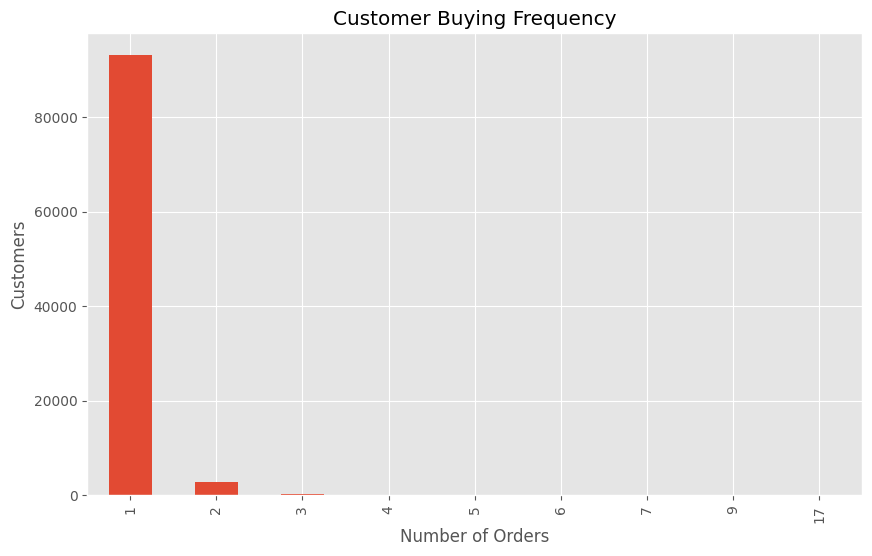

In [244]:
plt.figure(figsize=(10,6))

customer_orders.value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Customer Buying Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Customers')

plt.show()

**Step 13: Customer Segment Analysis**

Using engineered feature.

In [247]:
customer_spend = master_df.groupby(
    'customer_unique_id'
)['payment_value'].sum().reset_index()

customer_spend.columns = [
    'customer_unique_id',
    'customer_total_spend'
]

In [248]:
master_df = master_df.merge(
    customer_spend,
    on='customer_unique_id',
    how='left'
)

In [249]:
master_df['customer_segment'] = pd.cut(
    master_df['customer_total_spend'],

    bins=[0,100,500,1000,100000],

    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium'
    ]
)

In [250]:
master_df[
    [
        'customer_unique_id',
        'customer_total_spend',
        'customer_segment'
    ]
].drop_duplicates().head(20)

,customer_unique_id,customer_total_spend,customer_segment
0,7c396fd4830fd04220f754e42b4e5bff,82.82,Low Value
3,af07308b275d755c9edb36a90c618231,141.46,Medium Value
4,3a653a41f6f9fc3d2a113cf8398680e8,179.12,Medium Value
5,7c142cf63193a1473d2e66489a9ae977,72.20,Low Value
6,72632f0f9dd73dfee390c9b22eb56dd6,28.62,Low Value
7,80bb27c7c16e8f973207a5086ab329e2,175.26,Medium Value
8,36edbb3fb164b1f16485364b6fb04c73,65.95,Low Value
9,932afa1e708222e5821dac9cd5db4cae,75.16,Low Value
10,39382392765b6dc74812866ee5ee92a7,35.95,Low Value
11,299905e3934e9e181bfb2e164dd4b4f8,169.76,Medium Value


In [251]:
segment_analysis = master_df.groupby(
    'customer_segment'
)['customer_unique_id'].nunique()

segment_analysis

/tmp/ipykernel_18236/491905462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = master_df.groupby(


,customer_unique_id
customer_segment,
Low Value,42699
Medium Value,46113
High Value,4826
Premium,2454


In [252]:
segment_analysis = master_df.groupby(
    'customer_segment'
)['customer_unique_id'].nunique()

segment_analysis

/tmp/ipykernel_18236/491905462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = master_df.groupby(


,customer_unique_id
customer_segment,
Low Value,42699
Medium Value,46113
High Value,4826
Premium,2454


**Plot Customer Segments**

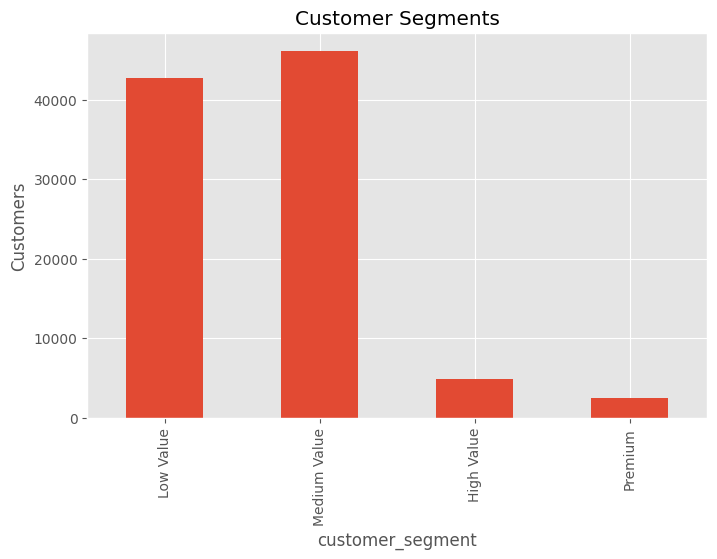

In [253]:
segment_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments')
plt.ylabel('Customers')

plt.show()

**SECTION C — BASKET SIZE ANALYSIS**

Important for recommendation systems.

**Step 14 — Basket Size Statistics**

In [256]:
basket_size = master_df.groupby(
    'order_id'
)['product_id'].count().reset_index()

basket_size.columns = [
    'order_id',
    'basket_size'
]

In [257]:
master_df = master_df.merge(
    basket_size,
    on='order_id',
    how='left'
)

In [258]:
master_df[
    ['order_id', 'basket_size']
].head()

,order_id,basket_size
0,e481f51cbdc54678b7cc49136f2d6af7,3
1,e481f51cbdc54678b7cc49136f2d6af7,3
2,e481f51cbdc54678b7cc49136f2d6af7,3
3,53cdb2fc8bc7dce0b6741e2150273451,1
4,47770eb9100c2d0c44946d9cf07ec65d,1


In [259]:
basket_stats = master_df[
    ['order_id', 'basket_size']
].drop_duplicates()

basket_stats['basket_size'].describe()

,basket_size
count,99441.000000
mean,1.189751
std,0.756632
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,63.000000


**Step 15 — Average Basket Size**

In [260]:
avg_basket_size = (
    basket_stats['basket_size']
    .mean()
)

print(
    "Average Basket Size:",
    avg_basket_size
)

Average Basket Size: 1.1897507064490502


**Step 16 — Basket Size Distribution**

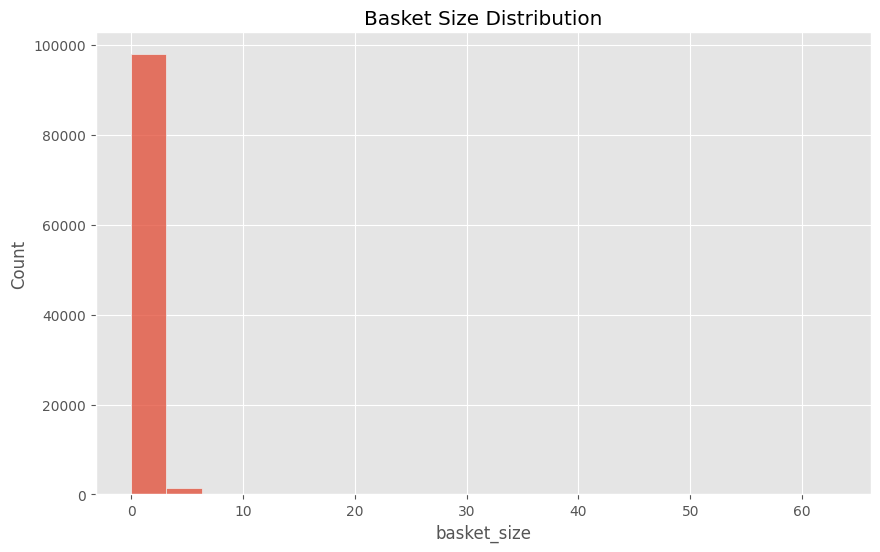

In [261]:
plt.figure(figsize=(10,6))

sns.histplot(
    basket_stats['basket_size'],
    bins=20
)

plt.title('Basket Size Distribution')

plt.show()

**SECTION D — SALES TREND ANALYSIS**

Very important for business storytelling.

**Step 17: Monthly Revenue**

In [264]:
master_df['order_purchase_timestamp'] = pd.to_datetime(
    master_df['order_purchase_timestamp']
)

In [265]:
master_df['purchase_month'] = (
    master_df['order_purchase_timestamp']
    .dt.month_name()
)

In [266]:
master_df[['order_purchase_timestamp', 'purchase_month']].head()

,order_purchase_timestamp,purchase_month
0,2017-10-02 10:56:33,October
1,2017-10-02 10:56:33,October
2,2017-10-02 10:56:33,October
3,2018-07-24 20:41:37,July
4,2018-08-08 08:38:49,August


In [267]:
monthly_sales = master_df.groupby(
    'purchase_month'
)['payment_value'].sum()

monthly_sales

,payment_value
purchase_month,
April,2012499.64
August,2133110.99
December,1060969.25
February,1679187.10
January,1616267.67
July,2111509.92
June,1913460.58
March,2034439.48
May,2249436.06


**Step 18: Revenue Trend Chart**

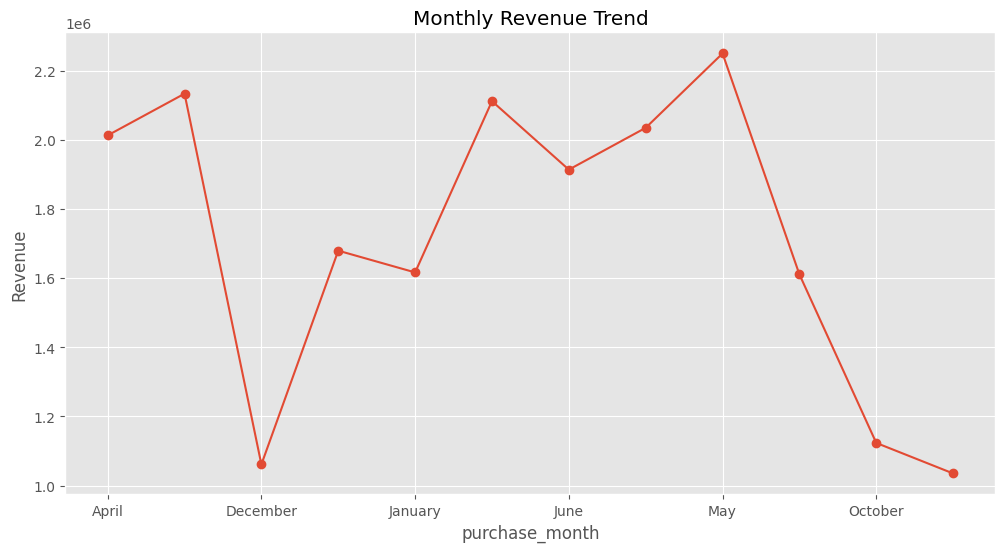

In [268]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

**Step 19: Monthly Order Trend**

In [269]:
monthly_orders = master_df.groupby(
    'purchase_month'
)['order_id'].nunique()

monthly_orders

,order_id
purchase_month,
April,9343
August,10843
December,5674
February,8508
January,8069
July,10318
June,9412
March,9893
May,10573


**Plot Monthly Orders**

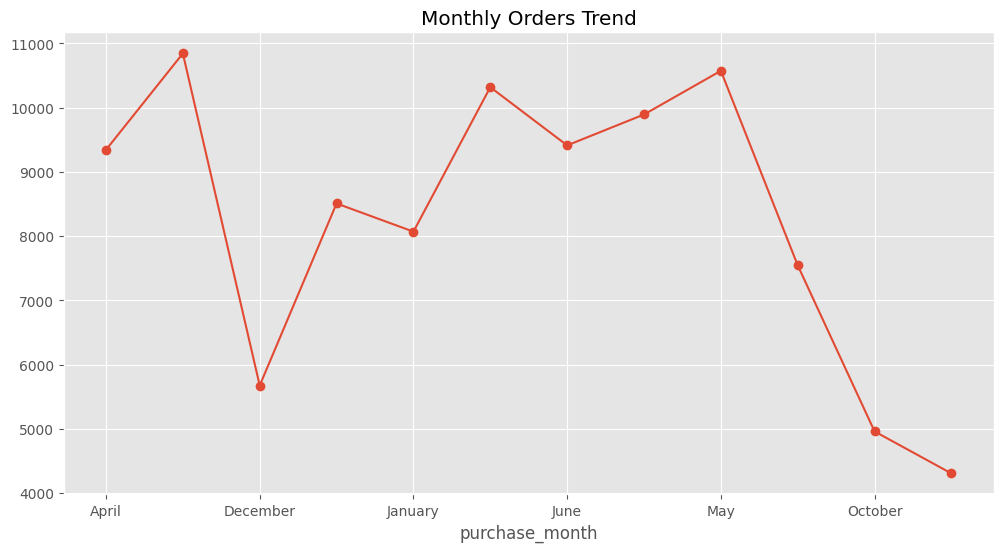

In [270]:
monthly_orders.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Orders Trend')

plt.show()

**SECTION E: PRODUCT ANALYSIS**

**Step 20 — Top Product Categories**

In [271]:
top_categories = master_df.groupby(
    'product_category_name_english'
)['payment_value'].sum().sort_values(
    ascending=False
).head(10)

top_categories

,payment_value
product_category_name_english,
bed_bath_table,1743998.80
health_beauty,1662963.59
computers_accessories,1599481.06
furniture_decor,1443963.61
watches_gifts,1430553.48
sports_leisure,1400223.07
housewares,1097900.09
auto,855095.68
garden_tools,840721.59


**Step 21: Plot Top Categories**

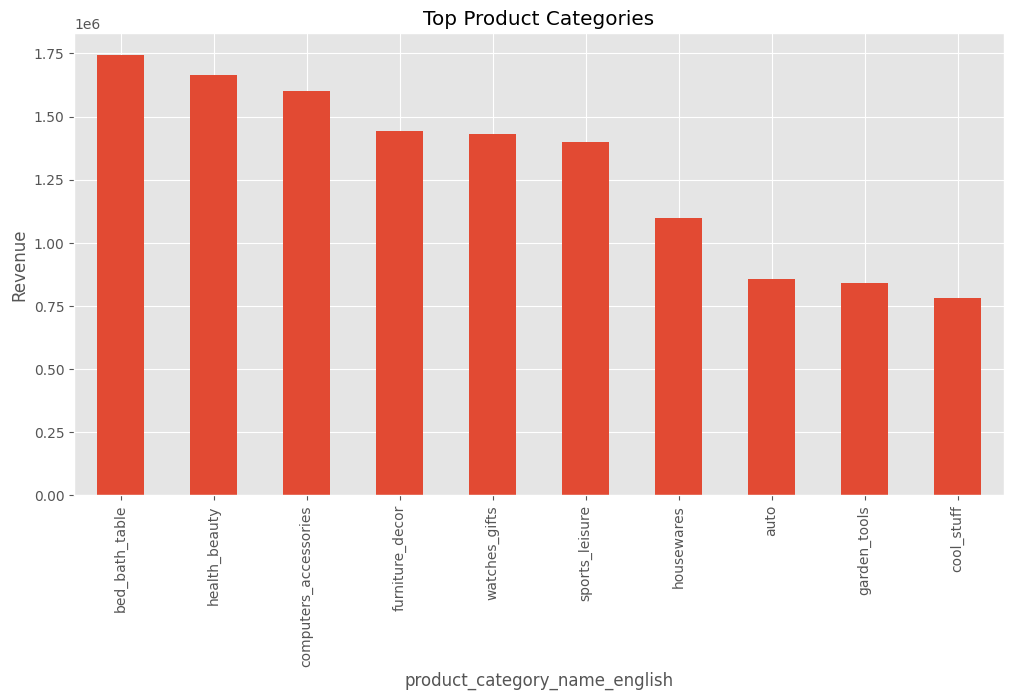

In [272]:
plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title('Top Product Categories')
plt.ylabel('Revenue')

plt.show()

**Step 22: Most Frequently Purchased Products**

In [273]:
top_products = master_df[
    'product_id'
].value_counts().head(10)

top_products

,count
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,536
99a4788cb24856965c36a24e339b6058,528
422879e10f46682990de24d770e7f83d,508
389d119b48cf3043d311335e499d9c6b,406
368c6c730842d78016ad823897a372db,398
53759a2ecddad2bb87a079a1f1519f73,391
d1c427060a0f73f6b889a5c7c61f2ac4,357
53b36df67ebb7c41585e8d54d6772e08,327
154e7e31ebfa092203795c972e5804a6,295


**SECTION F — PAYMENT ANALYSIS**

**Step 23: Payment Method Analysis**

In [274]:
payment_method = master_df[
    'payment_type'
].value_counts()

**Step 24: Payment Method Pie Chart**

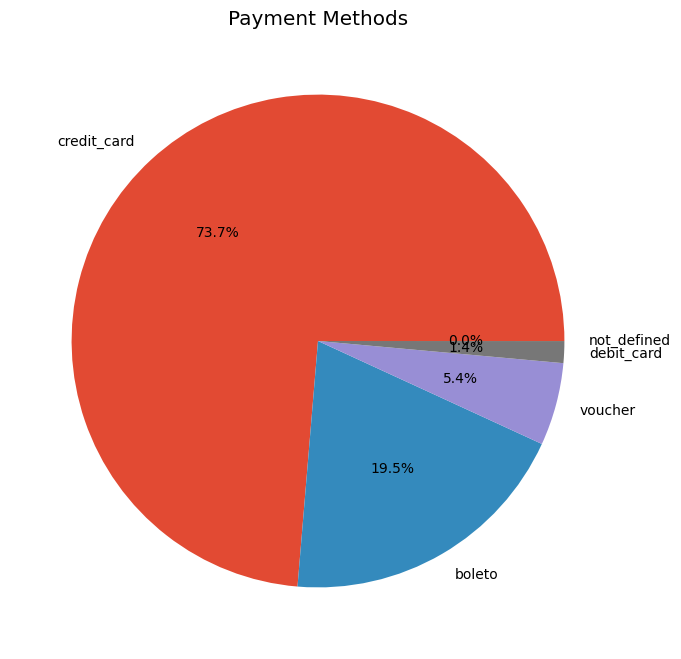

In [275]:
plt.figure(figsize=(8,8))

payment_method.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Payment Methods')

plt.ylabel('')

plt.show()

**Step 25: Installment Analysis**

Using engineered feature.

In [276]:
master_df['installment_order'] = np.where(
    master_df['payment_installments'] > 1,
    1,
    0
)


installment_orders = master_df[
    'installment_order'
].value_counts()

installment_orders




,count
installment_order,
1,59691
0,59452


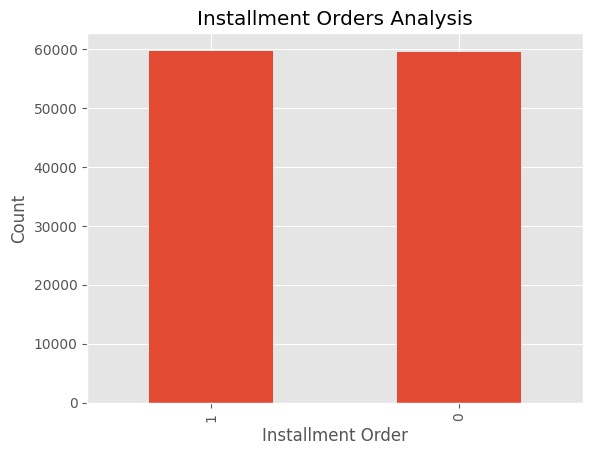

In [277]:
installment_orders.plot(kind='bar')

plt.title('Installment Orders Analysis')

plt.xlabel('Installment Order')

plt.ylabel('Count')

plt.show()

The installment payment analysis shows that customers are almost evenly split between installment-based purchases and full upfront payments. Around 59,691 orders were placed using installments, while 59,452 orders were paid in a single payment. This indicates that installment options play a significant role in customer purchasing behavior and may encourage higher-value purchases by providing flexible payment options.

**SECTION G: REVIEW ANALYSIS**

**Step 26: Review Score Distribution**

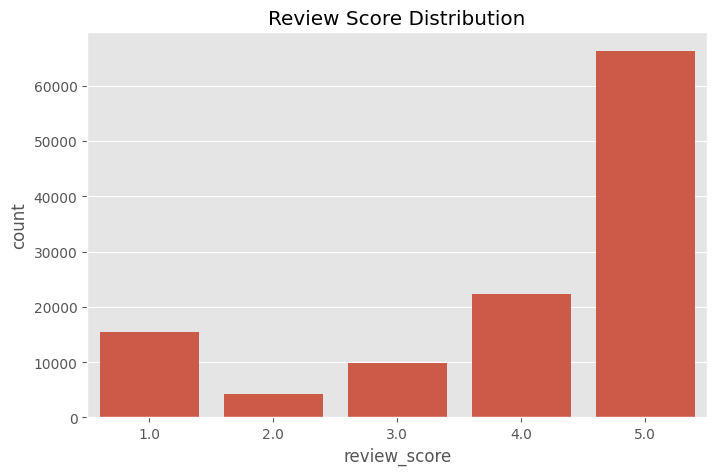

In [278]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=master_df
)

plt.title('Review Score Distribution')

plt.show()

**Step 27: Positive vs Negative Reviews**

**What 0 and 1 Mean**


1.   1	Positive Reviewist item
2.   0	Negative Review





In [280]:
master_df['positive_review'] = np.where(
    master_df['review_score'] >= 4,
    1,
    0
)

In [281]:
master_df[
    ['review_score', 'positive_review']
].head()

,review_score,positive_review
0,4.0,1
1,4.0,1
2,4.0,1
3,4.0,1
4,5.0,1


In [282]:
review_analysis = master_df[
    'positive_review'
].value_counts()

review_analysis

,count
positive_review,
1,88662
0,30481


**Plot Positive Reviews**

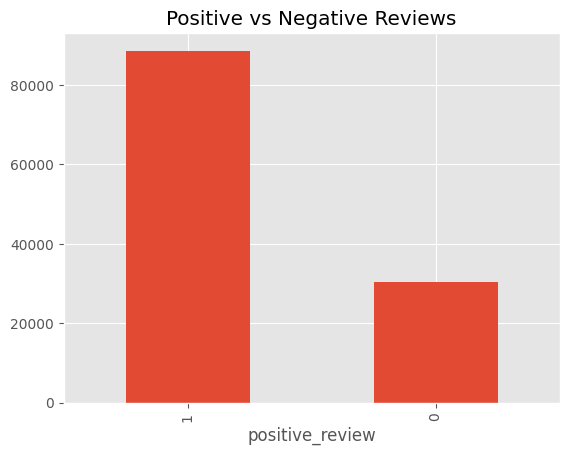

In [284]:
review_analysis.plot(
    kind='bar'
)

plt.title('Positive vs Negative Reviews')

plt.show()

The review analysis indicates that the majority of customers had a positive shopping experience on the platform. Approximately 88,662 reviews were classified as positive, while only 30,481 reviews were negative. This suggests strong customer satisfaction levels, likely influenced by factors such as product quality, delivery performance, and overall service experience. The significantly higher number of positive reviews reflects favorable customer perception and trust in the e-commerce platform.


**SECTION H: DELIVERY ANALYSIS**

**Step 28: Delivery Time Statistics**

In [285]:
master_df['delivery_days'].describe()

,delivery_days
count,115722.000000
mean,12.022589
std,9.454922
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**Step 29: Delivery Time Distribution**

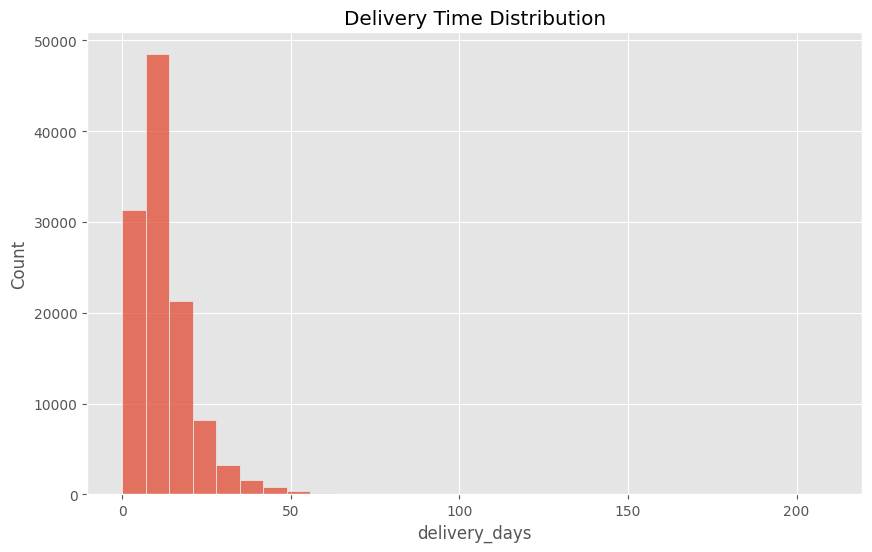

In [286]:
plt.figure(figsize=(10,6))

sns.histplot(
    master_df['delivery_days'],
    bins=30
)

plt.title('Delivery Time Distribution')

plt.show()

**Step 30: Delivery vs Review Score**

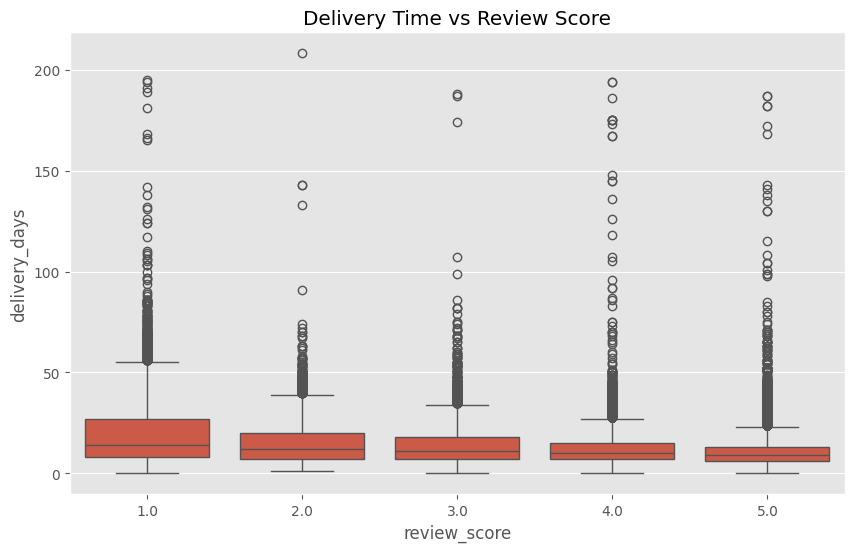

In [287]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='review_score',
    y='delivery_days',
    data=master_df
)

plt.title(
    'Delivery Time vs Review Score'
)

plt.show()

**Step 31: Late Delivery Analysis**

Using engineered feature.

In [288]:
late_delivery = master_df[
    'is_late_delivery'
].value_counts()

late_delivery

,count
is_late_delivery,
0,111584
1,7559


**Plot Late Deliveries**

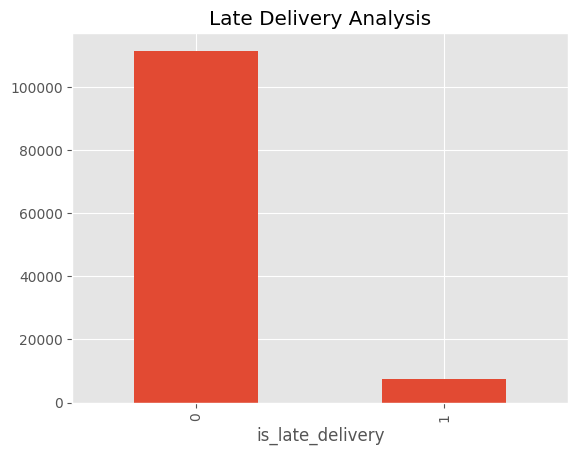

In [289]:
late_delivery.plot(
    kind='bar'
)

plt.title('Late Delivery Analysis')

plt.show()

The late delivery analysis shows that the majority of orders were delivered on or before the estimated delivery date. Around 111,584 orders were delivered on time, while only 7,559 orders experienced delays. This indicates strong logistics and supply chain performance by the platform, contributing positively to customer satisfaction and overall shopping experience. The relatively low number of delayed deliveries suggests efficient order fulfillment and delivery management.

**SECTION I: GEOGRAPHICAL ANALYSIS**

**Step 32: Top States by Orders**

In [290]:
top_states = master_df[
    'customer_state'
].value_counts().head(10)

top_states

,count
customer_state,
SP,50265
RJ,15518
MG,13819
RS,6573
PR,6043
SC,4345
BA,4091
DF,2516
GO,2466


**Plot State Orders**

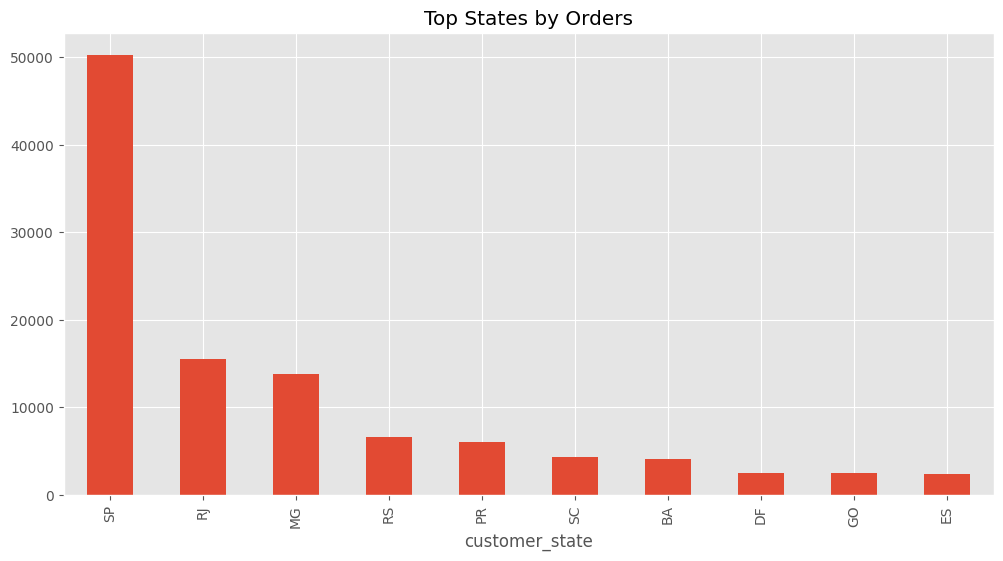

In [291]:
plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title('Top States by Orders')

plt.show()

**SECTION J: CORRELATION ANALYSIS**

**Step 33: Correlation Matrix**

In [292]:
corr_cols = [
    'payment_value',
    'freight_value',
    'delivery_days',
    'basket_size',
    'review_score'
]

corr_matrix = master_df[
    corr_cols
].corr()

**Step 34: Heatmap**

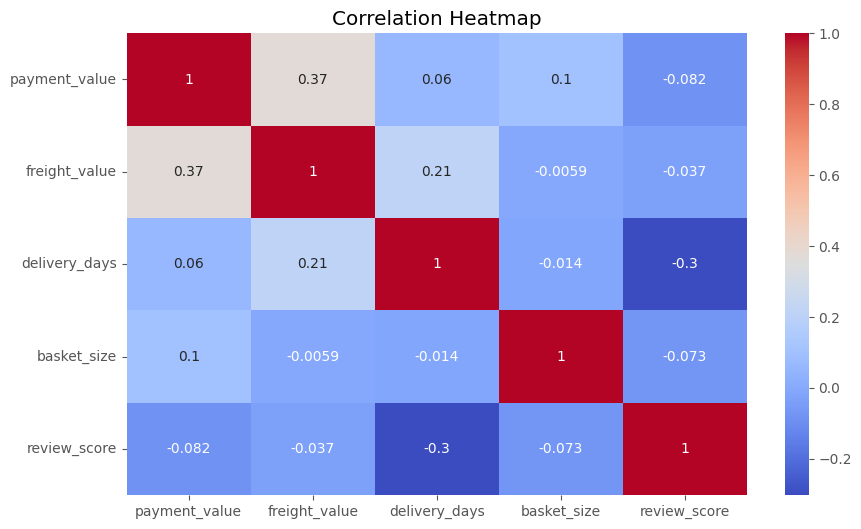

In [293]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

**IMPORTANT BUSINESS INSIGHTS**

**Customer Insights**
1. Majority customers are one-time buyers.
2. Premium customers contribute significant revenue.

**Product Insights**
1. Electronics and home products dominate revenue.
2. Some products are frequently purchased together.

**Delivery Insights**
1. Late deliveries negatively affect reviews.
2. Faster deliveries lead to higher ratings.

**Payment Insights**
1. Credit cards are the dominant payment method.
2. Installment payments are common.

#**PROBABILITY ANALYSIS**

**SECTION 1 — OVERALL REPEAT PURCHASE PROBABILITY**

This directly satisfies:

“Likelihood of repeat purchase”

**Step 1 — Total Customers**

In [294]:
total_customers = master_df[
    'customer_unique_id'
].nunique()

print(
    "Total Customers:",
    total_customers
)

Total Customers: 96096


**Step 2 — Orders Per Customer**

In [296]:
customer_orders = master_df.groupby(
    'customer_unique_id'
)['order_id'].nunique()

customer_orders.head()

,order_id
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1


**Step 3 — Repeat Customers**

In [297]:
repeat_customers = customer_orders[
    customer_orders > 1
]

repeat_customer_count = repeat_customers.count()

print(
    "Repeat Customers:",
    repeat_customer_count
)

Repeat Customers: 2997


**Step 4 — Repeat Purchase Probability**

**P(Repeat Purchase) = Total Customers / Customers with Multiple Orders​**

In [298]:
repeat_purchase_probability = (
    repeat_customer_count
    /
    total_customers
)

print(
    "Repeat Purchase Probability:",
    round(repeat_purchase_probability,4)
)

Repeat Purchase Probability: 0.0312


**Step 5 — Convert to Percentage**

In [299]:
repeat_purchase_percentage = (
    repeat_purchase_probability * 100
)

print(
    "Repeat Purchase Percentage:",
    round(repeat_purchase_percentage,2),
    "%"
)

Repeat Purchase Percentage: 3.12 %


**Step 6 — Visualization**

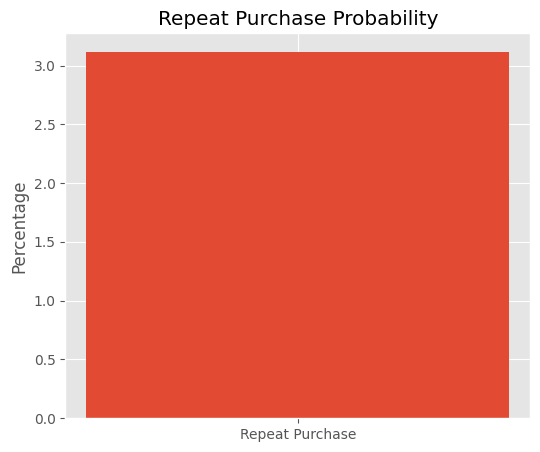

In [300]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Repeat Purchase'],
    [repeat_purchase_percentage]
)

plt.ylabel('Percentage')

plt.title(
    'Repeat Purchase Probability'
)

plt.show()

**Insight**

The overall repeat purchase analysis reveals that the repeat purchase probability of the platform is approximately 0.0312, which translates to a repeat purchase rate of 3.12%. This indicates that only a small proportion of customers returned to place additional orders, while the vast majority of customers were one-time buyers.

The low repeat purchase percentage suggests that although the platform is successful in attracting customers and generating transactions, customer retention remains a significant challenge. This may indicate that customers are using the platform for occasional or need-based purchases rather than developing long-term purchasing loyalty.

From a business perspective, this presents a strong opportunity for the company to improve retention-focused strategies such as personalized product recommendations, loyalty programs, targeted discounts, email marketing campaigns, subscription-based offers, and improved post-purchase engagement. Increasing repeat purchase behavior can significantly improve customer lifetime value, reduce customer acquisition costs, and drive sustainable long-term revenue growth.


**SECTION 2 — CATEGORY-WISE REPEAT PURCHASE PROBABILITY**

This shows:



*   which product categories retain customers better




**Step 7 — Orders Per Category**

In [301]:
category_repeat = master_df.groupby(
    [
        'product_category_name_english',
        'customer_unique_id'
    ]
)['order_id'].nunique().reset_index()

**Step 8 — Repeat Customer Flag**

In [302]:
category_repeat['repeat_customer'] = np.where(
    category_repeat['order_id'] > 1,
    1,
    0
)

**Step 9 — Category-wise Probability**

In [303]:
category_probability = category_repeat.groupby(
    'product_category_name_english'
)['repeat_customer'].mean().sort_values(
    ascending=False
)

category_probability.head(10)

,repeat_customer
product_category_name_english,
arts_and_craftmanship,0.095238
home_appliances,0.073969
home_comfort_2,0.043478
diapers_and_hygiene,0.038462
furniture_bedroom,0.032967
fashion_bags_accessories,0.030590
bed_bath_table,0.027556
sports_leisure,0.024484
furniture_decor,0.020421


**Step 10 — Visualization**

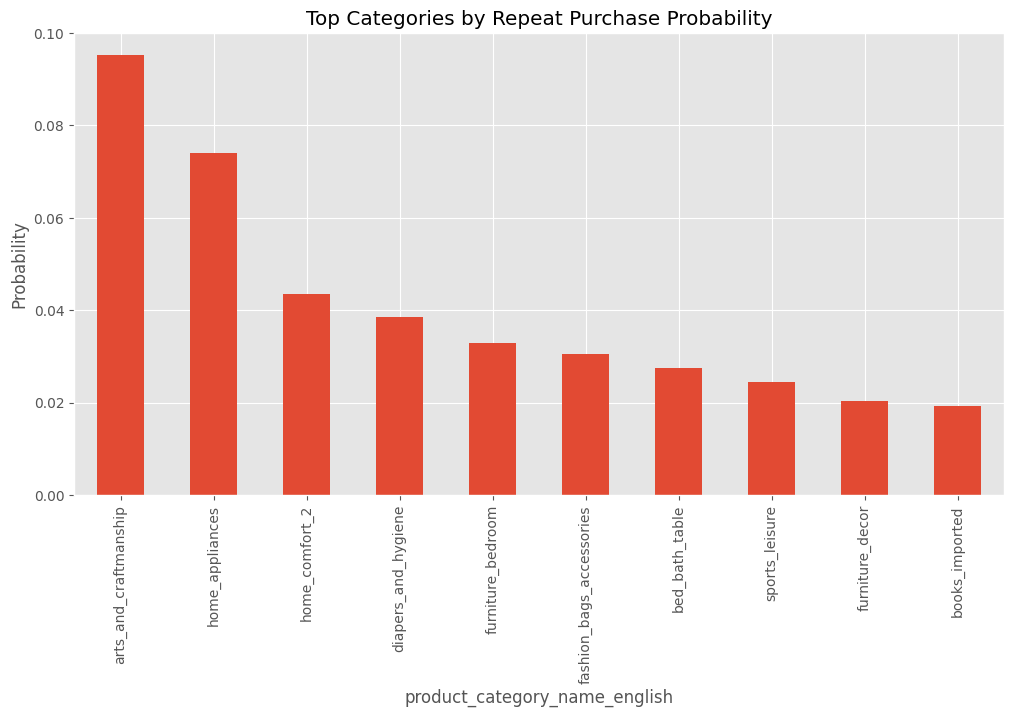

In [304]:
plt.figure(figsize=(12,6))

category_probability.head(10).plot(
    kind='bar'
)

plt.title(
    'Top Categories by Repeat Purchase Probability'
)

plt.ylabel('Probability')

plt.show()

**Insight**

The category-wise repeat purchase probability analysis reveals that the `arts_and_craftmanship` category has the highest repeat purchase probability at approximately 9.52%, followed by `home_appliances` at 7.40% and `home_comfort_2` at 4.35%. Categories such as `diapers_and_hygiene`, `furniture_bedroom`, and `fashion_bags_accessories` also demonstrate comparatively higher repeat purchase tendencies. On the other hand, categories like `books_imported` and `furniture_decor` show relatively lower repeat purchase probabilities among the top categories analyzed.

These results suggest that customers purchasing household utility, comfort, and lifestyle-related products are more likely to return for repeat purchases, indicating recurring demand and stronger customer dependency in these categories. Such categories present strong opportunities for targeted retention campaigns, personalized recommendations, subscription-based offers, and cross-selling strategies to further improve customer loyalty and long-term revenue generation.


**SECTION 3 — PAYMENT TYPE REPEAT PURCHASE PROBABILITY**

This analyzes:



*   whether payment method influences loyalty




**Step 11 — Orders Per Payment Type**

In [305]:
payment_repeat = master_df.groupby(
    [
        'payment_type',
        'customer_unique_id'
    ]
)['order_id'].nunique().reset_index()

**Step 12 — Repeat Flag**

In [306]:
payment_repeat['repeat_customer'] = np.where(
    payment_repeat['order_id'] > 1,
    1,
    0
)

**Step 13 — Payment-wise Probability**

In [307]:
payment_probability = payment_repeat.groupby(
    'payment_type'
)['repeat_customer'].mean().sort_values(
    ascending=False
)

payment_probability

,repeat_customer
payment_type,
credit_card,0.029355
voucher,0.026064
boleto,0.022965
debit_card,0.009914
not_defined,0.000000


**Step 14 — Visualization**

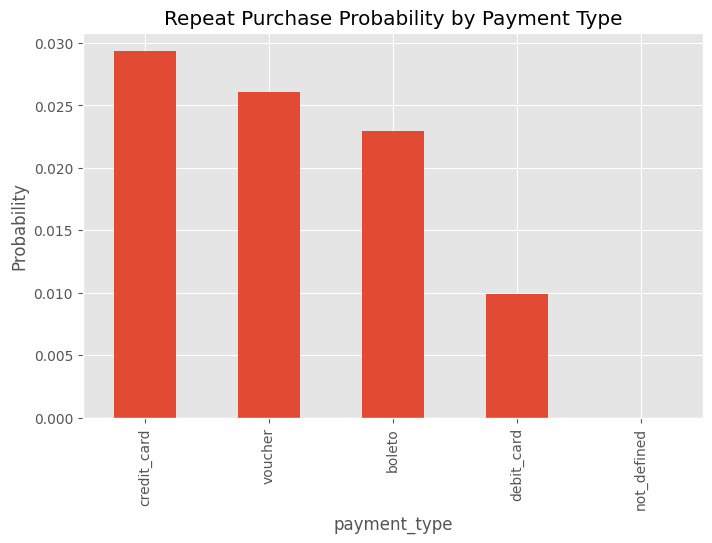

In [308]:
plt.figure(figsize=(8,5))

payment_probability.plot(
    kind='bar'
)

plt.title(
    'Repeat Purchase Probability by Payment Type'
)

plt.ylabel('Probability')

plt.show()

**Insight**

The payment-type probability analysis shows that customers using credit cards have the highest repeat purchase probability at approximately 2.94%, followed by voucher payments at 2.61% and boleto payments at 2.30%. Debit card users exhibit the lowest repeat purchase probability among the major payment methods at around 0.99%, while the `not_defined` category shows no repeat purchases. This suggests that customers using credit cards are comparatively more likely to make repeat purchases, possibly due to greater payment flexibility and ease of transaction.